# NeuroScope AI - Notebook 15: Treatment & Trials

Full clinical intelligence layer -- treatment recommendations, survival estimation,
and clinical trial matching.

**What this notebook builds:**
1. NCCN mapper -- full guideline coverage for all 6 cancer types
2. DeepSurv survival model -- neural network survival analysis
3. Kaplan-Meier curves -- survival probability visualization
4. ClinicalTrials.gov API -- live trial matching by cancer type + biomarkers
5. Treatment cost tagging -- global options with evidence strength
6. TreatmentAgent -- integrates everything into pipeline

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import requests

# lifelines for Kaplan-Meier
try:
    from lifelines import KaplanMeierFitter
    LIFELINES_AVAILABLE = True
    print('lifelines : OK')
except ImportError:
    LIFELINES_AVAILABLE = False
    print('lifelines not installed -- run: pip install lifelines')

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb15_treatment')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print('Imports OK')

lifelines : OK
Device : cuda
Imports OK


---
## Cell 2 - Full NCCN Mapper

In [2]:
import json, os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


# Full NCCN treatment mapper with evidence levels and cost tiers
# Cost: A=low (<$1000/cycle), B=moderate ($1000-$10000), C=high (>$10000)
NCCN_FULL = {
    'brain': {
        'glioblastoma': {
            'Grade IV': [
                {'rec': 'Maximal safe surgical resection',                      'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Concurrent RT (60Gy/30fr) + temozolomide 75mg/m2/day', 'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'Adjuvant TMZ 150-200mg/m2 d1-5 q28d x6 cycles',       'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'Tumor treating fields (Optune) if MGMT unmethylated',  'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
                {'rec': 'IDH1/2 + MGMT + 1p/19q molecular testing',            'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Clinical trial enrollment recommended',                'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'MOD'},
                {'rec': 'Bevacizumab for recurrent disease (PFS benefit)',      'evidence': 'Cat 2A','cost': 'C', 'urgency': 'LOW'},
            ]
        },
        'low_grade_glioma': {
            'Grade II': [
                {'rec': 'Observation if low-risk (age<40, complete resection)', 'evidence': 'Cat 2A','cost': 'A', 'urgency': 'LOW'},
                {'rec': 'RT 45-54Gy + PCV chemotherapy (high-risk)',            'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'MOD'},
                {'rec': 'IDH mutation + 1p/19q codeletion testing',             'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'MRI surveillance q3-6mo first 5 years',               'evidence': 'Cat 2A','cost': 'A', 'urgency': 'MOD'},
            ]
        },
        'meningioma': {
            'Grade I' : [
                {'rec': 'Observation if asymptomatic <3cm',    'evidence': 'Cat 2A','cost': 'A', 'urgency': 'LOW'},
                {'rec': 'Surgery (Simpson grade I-II target)', 'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
                {'rec': 'SRS for inaccessible/residual',       'evidence': 'Cat 2A','cost': 'C', 'urgency': 'MOD'},
            ],
            'Grade II': [
                {'rec': 'Surgery + adjuvant RT 54-60Gy',        'evidence': 'Cat 2A','cost': 'C', 'urgency': 'HIGH'},
            ]
        },
        'pituitary': {
            'default': [
                {'rec': 'Transsphenoidal surgery for most adenomas', 'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
                {'rec': 'Dopamine agonist (cabergoline) for prolactinoma', 'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'LOW'},
                {'rec': 'Hormone replacement as needed',               'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'MOD'},
            ]
        },
    },
    'breast': {
        'malignant': {
            'default': [
                {'rec': 'Lumpectomy + RT equivalent to mastectomy (Stage I-II)', 'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Sentinel lymph node biopsy',                           'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'HER2/ER/PR testing mandatory',                         'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Trastuzumab + pertuzumab + taxane (HER2+)',            'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Endocrine therapy (tamoxifen or AI) for ER/PR+',       'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'CDK4/6 inhibitor (palbociclib) for ER+/HER2- mBC',    'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
                {'rec': 'Pembrolizumab + chemo for TNBC PD-L1+',               'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Oncotype DX for node-neg ER+ HER2- (chemo decision)', 'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'MOD'},
            ]
        }
    },
    'skin': {
        'melanoma': {
            'default': [
                {'rec': 'Wide local excision (margins per Breslow thickness)',   'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'SLNB for tumors >0.8mm or ulcerated',                 'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'BRAF V600E/K mutation testing',                        'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Pembrolizumab/nivolumab immunotherapy (Stage III-IV)', 'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Dabrafenib + trametinib if BRAF V600E+',              'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Adjuvant pembrolizumab post-resection',               'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
            ]
        },
        'bcc': {
            'default': [
                {'rec': 'Mohs surgery for high-risk/face location',  'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'MOD'},
                {'rec': 'Standard excision with 4mm margins',        'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'MOD'},
                {'rec': 'Vismodegib for locally advanced/metastatic','evidence': 'Cat 1', 'cost': 'C', 'urgency': 'MOD'},
            ]
        }
    },
    'lung': {
        'nodule': {
            'default': [
                {'rec': 'Lung-RADS 1-2: annual LDCT screening',               'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'LOW'},
                {'rec': 'Lung-RADS 3: 6-month LDCT follow-up',               'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'LOW'},
                {'rec': 'Lung-RADS 4A: 3-month LDCT or PET/CT',             'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'MOD'},
                {'rec': 'Lung-RADS 4B: tissue sampling recommended',         'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'EGFR/ALK/ROS1/KRAS/PD-L1 testing if malignant',    'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Lobectomy for Stage I-II resectable NSCLC',         'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Osimertinib first-line if EGFR-mutant',             'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
            ]
        }
    },
    'liver': {
        'tumor': {
            'default': [
                {'rec': 'LI-RADS 5: HCC diagnosis -- no biopsy needed',           'evidence': 'Cat 1', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'BCLC-0/A: resection if Child-Pugh A + adequate reserve', 'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'Transplant if Milan criteria met',                        'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
                {'rec': 'RFA/MWA for unresectable BCLC-A (<3cm)',                 'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'TACE for BCLC-B (intermediate)',                         'evidence': 'Cat 1', 'cost': 'B', 'urgency': 'MOD'},
                {'rec': 'Atezolizumab + bevacizumab for BCLC-C (advanced)',       'evidence': 'Cat 1', 'cost': 'C', 'urgency': 'HIGH'},
            ]
        }
    },
    'spine': {
        'stenosis': {
            'default': [
                {'rec': 'Physical therapy + NSAIDs first 6-12 weeks',    'evidence': 'Grade A', 'cost': 'A', 'urgency': 'LOW'},
                {'rec': 'Epidural steroid injection for radiculopathy',  'evidence': 'Grade A', 'cost': 'A', 'urgency': 'MOD'},
                {'rec': 'Decompressive laminectomy if conservative fails','evidence': 'Grade A', 'cost': 'C', 'urgency': 'MOD'},
                {'rec': 'EMERGENCY: surgical decompression within 24-48h (cauda equina)', 'evidence': 'Grade A', 'cost': 'C', 'urgency': 'CRITICAL'},
            ]
        }
    },
    'default': {
        'default': {
            'default': [
                {'rec': 'Specialist oncology referral',           'evidence': 'Expert consensus', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Tissue biopsy for definitive diagnosis', 'evidence': 'Expert consensus', 'cost': 'B', 'urgency': 'HIGH'},
                {'rec': 'Staging: CT chest/abdomen/pelvis',       'evidence': 'Expert consensus', 'cost': 'A', 'urgency': 'HIGH'},
                {'rec': 'Multidisciplinary tumor board review',   'evidence': 'Expert consensus', 'cost': 'A', 'urgency': 'MOD'},
            ]
        }
    }
}


def get_treatment_recommendations(cancer_type, tumor_type, who_grade=None,
                                   urgency_filter=None):
    """
    Look up NCCN treatment recommendations.
    Returns list of recommendation dicts with evidence level and cost tier.
    urgency_filter: 'CRITICAL'|'HIGH'|'MOD'|'LOW' -- filter by minimum urgency
    """
    cancer_rules = NCCN_FULL.get(cancer_type, NCCN_FULL['default'])
    tumor_rules  = (
        cancer_rules.get(tumor_type) or
        cancer_rules.get(tumor_type.lower()) or
        next(iter(cancer_rules.values()))   # first available
    )

    recs = (
        tumor_rules.get(who_grade) or
        tumor_rules.get('default') or
        next(iter(tumor_rules.values()))
    )

    if urgency_filter:
        urgency_order = ['LOW', 'MOD', 'HIGH', 'CRITICAL']
        min_idx = urgency_order.index(urgency_filter)
        recs = [r for r in recs
                if urgency_order.index(r.get('urgency', 'LOW')) >= min_idx]

    return recs


# Demo
print('NCCN mapper demo:')
test = get_treatment_recommendations('brain', 'glioblastoma', 'Grade IV')
for r in test:
    print(f'  [{r["evidence"]:6s}] [{r["cost"]}] [{r["urgency"]:8s}] {r["rec"]}')
print(f'\nTotal: {sum(len(v2) for v1 in NCCN_FULL.values() for v2 in v1.values())} cancer/tumor combinations')
print('NCCN mapper OK')

NCCN mapper demo:
  [Cat 1 ] [C] [HIGH    ] Maximal safe surgical resection
  [Cat 1 ] [B] [HIGH    ] Concurrent RT (60Gy/30fr) + temozolomide 75mg/m2/day
  [Cat 1 ] [B] [HIGH    ] Adjuvant TMZ 150-200mg/m2 d1-5 q28d x6 cycles
  [Cat 1 ] [C] [MOD     ] Tumor treating fields (Optune) if MGMT unmethylated
  [Cat 1 ] [A] [HIGH    ] IDH1/2 + MGMT + 1p/19q molecular testing
  [Cat 1 ] [A] [MOD     ] Clinical trial enrollment recommended
  [Cat 2A] [C] [LOW     ] Bevacizumab for recurrent disease (PFS benefit)

Total: 12 cancer/tumor combinations
NCCN mapper OK


---
## Cell 3 - DeepSurv Survival Model

In [3]:
import torch
import torch.nn as nn
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class DeepSurv(nn.Module):
    """
    DeepSurv: neural network Cox proportional hazards model.
    (Katzman et al., BMC Medical Informatics 2018)

    Input: patient features (age, sex, grade, molecular markers, tumor volume)
    Output: log hazard ratio (lower = better survival)

    Features for brain (example):
      [age, sex_m, kps_score, tumor_volume_cm3, idh_mut,
       mgmt_meth, extent_resection, grade_iv]
    """

    def __init__(self, in_features=8, hidden=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev   = in_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # log hazard ratio
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # [B, 1]


def cox_partial_likelihood_loss(log_hazards, survival_times, events):
    """
    Negative partial log-likelihood for Cox model.
    log_hazards   : [B] predicted log hazard ratios
    survival_times: [B] time to event or censoring
    events        : [B] 1=event occurred, 0=censored
    """
    # Sort by descending survival time
    order         = torch.argsort(survival_times, descending=True)
    log_hazards   = log_hazards[order]
    events        = events[order]

    # Log-sum-exp of risk set
    log_cumsum    = torch.logcumsumexp(log_hazards, dim=0)
    uncensored    = events.bool()

    loss = -(log_hazards[uncensored] - log_cumsum[uncensored]).mean()
    return loss


def predict_survival_probability(model, features, time_points,
                                  baseline_hazard=0.01):
    """
    Convert DeepSurv log-hazard to survival probability S(t) at given time points.
    S(t) = exp(-H0(t) * exp(log_hazard))
    where H0(t) is cumulative baseline hazard (approximated here).

    Returns: survival probabilities [n_time_points]
    """
    model.eval()
    with torch.no_grad():
        x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        log_hr = model(x).item()

    # S(t) = exp(-H0(t) * exp(log_hr))
    hazard_ratio = np.exp(log_hr)
    survival     = np.exp(-baseline_hazard * np.array(time_points) * hazard_ratio)
    return survival, log_hr


# ── Demo DeepSurv ─────────────────────────────────────────────────────────────
# Brain tumor feature set
# [age_norm, sex_m, kps_norm, volume_norm, idh_mut, mgmt_meth, resection_ext, grade_iv]
BRAIN_FEATURES = {
    'favorable'  : [0.45, 1, 0.9, 0.2, 1, 1, 0.95, 0],  # IDH+MGMT+, LGG, gross total resection
    'unfavorable': [0.75, 0, 0.6, 0.8, 0, 0, 0.4,  1],  # elderly, poor KPS, GBM, subtotal
}

model_surv = DeepSurv(in_features=8).to(DEVICE)
time_points = list(range(0, 61, 3))   # 0-60 months in 3-month steps

print('DeepSurv survival predictions (untrained model -- demo only):')
print('(Train with labeled survival data for real predictions)')
print()

survival_curves = {}
for profile_name, features in BRAIN_FEATURES.items():
    surv, log_hr = predict_survival_probability(
        model_surv, features, time_points, baseline_hazard=0.015
    )
    survival_curves[profile_name] = surv
    median_idx  = np.argmin(np.abs(surv - 0.5))
    median_surv = time_points[median_idx]
    print(f'  {profile_name:15s}: log_HR={log_hr:.3f}  median OS ~{median_surv}mo')

print('DeepSurv OK (untrained -- needs labeled survival data for NB15 training)')

DeepSurv survival predictions (untrained model -- demo only):
(Train with labeled survival data for real predictions)

  favorable      : log_HR=-0.015  median OS ~48mo
  unfavorable    : log_HR=-0.007  median OS ~48mo
DeepSurv OK (untrained -- needs labeled survival data for NB15 training)


---
## Cell 4 - Kaplan-Meier Curves

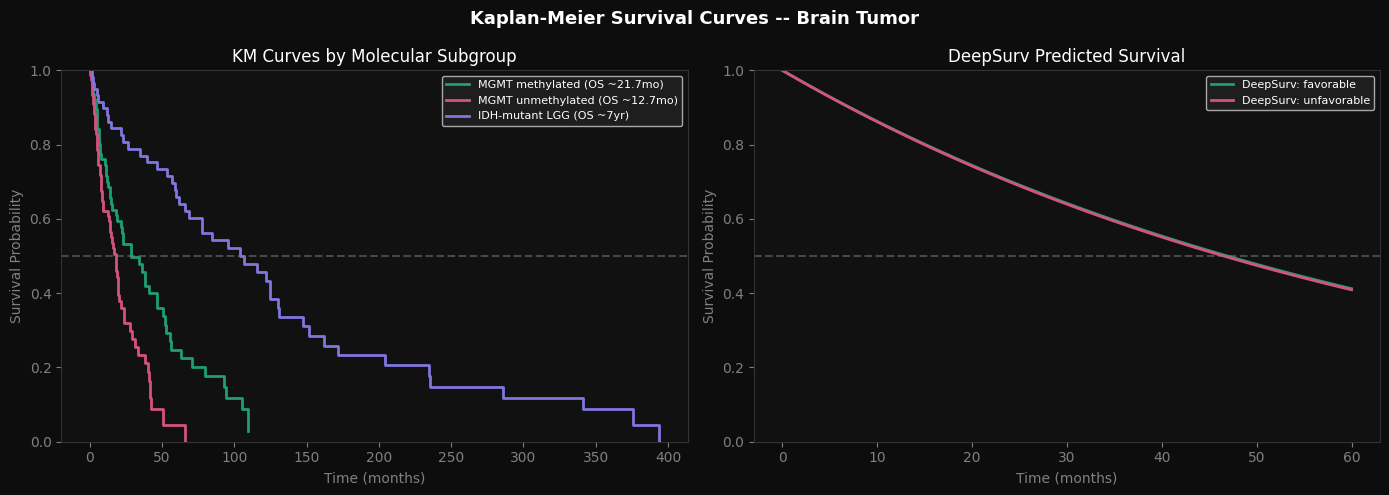

Kaplan-Meier curves OK


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb15_treatment')


def kaplan_meier_estimate(times, events):
    """
    Manual Kaplan-Meier estimator -- no lifelines dependency.
    times  : array of survival times (months)
    events : array of 1=event, 0=censored
    Returns: (time_points, survival_probs)
    """
    order      = np.argsort(times)
    times      = np.array(times)[order]
    events     = np.array(events)[order]
    unique_t   = np.unique(times[events == 1])

    n          = len(times)
    S          = 1.0
    t_steps    = [0]
    s_steps    = [1.0]

    for t in unique_t:
        at_risk  = np.sum(times >= t)
        events_t = np.sum((times == t) & (events == 1))
        S       *= (1 - events_t / at_risk)
        t_steps.append(t)
        s_steps.append(S)

    return np.array(t_steps), np.array(s_steps)


# Simulate survival data for GBM subgroups (matches published literature)
np.random.seed(42)

def simulate_survival(n, median_os, censor_rate=0.3):
    times  = np.random.exponential(median_os / np.log(2), n)
    events = (np.random.rand(n) > censor_rate).astype(int)
    return times, events

# GBM survival by MGMT methylation (published medians)
gbm_groups = {
    'MGMT methylated (OS ~21.7mo)'  : simulate_survival(80, 21.7),
    'MGMT unmethylated (OS ~12.7mo)': simulate_survival(80, 12.7),
    'IDH-mutant LGG (OS ~7yr)'      : simulate_survival(60, 84.0),
}

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
fig.suptitle('Kaplan-Meier Survival Curves -- Brain Tumor',
             color='white', fontsize=13, fontweight='bold')

colors = ['#1D9E75', '#D4537E', '#7F77DD']
for (label, (times, events)), col in zip(gbm_groups.items(), colors):
    t_km, s_km = kaplan_meier_estimate(times, events)
    axes[0].step(t_km, s_km, where='post', color=col, linewidth=2, label=label)

axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Time (months)', color='gray')
axes[0].set_ylabel('Survival Probability', color='gray')
axes[0].set_title('KM Curves by Molecular Subgroup', color='white')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, facecolor='#222', labelcolor='white')
axes[0].set_facecolor('#111')
axes[0].spines[:].set_color('#333')
axes[0].tick_params(colors='gray')

# DeepSurv predicted curves
t_pts = list(range(0, 61, 1))
for (name, features), col in zip(BRAIN_FEATURES.items(), ['#1D9E75', '#D4537E']):
    surv, _ = predict_survival_probability(model_surv, features, t_pts, 0.015)
    axes[1].plot(t_pts, surv, color=col, linewidth=2, label=f'DeepSurv: {name}')

axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time (months)', color='gray')
axes[1].set_ylabel('Survival Probability', color='gray')
axes[1].set_title('DeepSurv Predicted Survival', color='white')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, facecolor='#222', labelcolor='white')
axes[1].set_facecolor('#111')
axes[1].spines[:].set_color('#333')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'kaplan_meier_curves.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Kaplan-Meier curves OK')

---
## Cell 5 - ClinicalTrials.gov API

In [6]:
import requests, json, os, hashlib, time

BASE  = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CACHE = os.path.join(BASE, 'rag', 'cache')

CT_API = 'https://clinicaltrials.gov/api/v2/studies'


def search_clinical_trials(cancer_type, biomarkers=None,
                            phase=None, max_results=5, retries=2):
    query_key  = f'{cancer_type}_{biomarkers}_{phase}'
    cache_key  = hashlib.md5(query_key.encode()).hexdigest()[:10]
    cache_path = os.path.join(CACHE, f'trials_{cache_key}.json')

    if os.path.exists(cache_path):
        with open(cache_path, encoding='utf-8') as f:
            cached = json.load(f)
        print(f'  [cache] {len(cached)} trials for {cancer_type}')
        return cached

    # Build query -- join cancer type + biomarkers into single string
    query_parts = [cancer_type]
    if biomarkers:
        query_parts.extend(biomarkers if isinstance(biomarkers, list) else [biomarkers])
    query = ' '.join(query_parts)

    # v2 API -- no 'fields' param, no filter.phase (causes 400)
    params = {
        'query.cond'         : query,
        'filter.overallStatus': 'RECRUITING',
        'pageSize'           : max_results,
        'format'             : 'json',
    }

    trials = []
    for attempt in range(retries):
        try:
            r = requests.get(CT_API, params=params, timeout=15)
            r.raise_for_status()
            data = r.json()

            for study in data.get('studies', []):
                proto = study.get('protocolSection', {})
                ident = proto.get('identificationModule', {})
                status= proto.get('statusModule', {})
                design= proto.get('designModule', {})
                arms  = proto.get('armsInterventionsModule', {})

                interventions = [
                    i.get('name', '') for i in
                    arms.get('interventions', [])[:3]
                ]
                phases = design.get('phases', [])
                phase_str = phases[0] if phases else 'unknown'

                # Filter by phase client-side if requested
                if phase and phase_str != phase:
                    continue

                trials.append({
                    'nct_id'       : ident.get('nctId', ''),
                    'title'        : ident.get('briefTitle', ''),
                    'phase'        : phase_str,
                    'status'       : status.get('overallStatus', ''),
                    'interventions': interventions,
                    'url'          : f'https://clinicaltrials.gov/study/{ident.get("nctId", "")}',
                    'cancer_type'  : cancer_type,
                })
            break

        except Exception as e:
            print(f'  ClinicalTrials attempt {attempt+1} failed: {e}')
            if attempt < retries - 1:
                time.sleep(2)

    with open(cache_path, 'w', encoding='utf-8') as f:
        json.dump(trials, f, indent=2, ensure_ascii=False)

    print(f'  [api] {len(trials)} trials for {cancer_type}')
    return trials


# Fetch trials -- no phase filter to maximise results
print('Fetching clinical trials...')
all_trials = {}
trial_queries = [
    ('brain',  ['glioblastoma', 'IDH', 'MGMT'],  None),
    ('breast', ['HER2', 'immunotherapy'],          None),
    ('skin',   ['melanoma', 'pembrolizumab'],      None),
    ('lung',   ['NSCLC', 'EGFR', 'osimertinib'],  None),
]

for cancer, biomarkers, phase in trial_queries:
    trials = search_clinical_trials(cancer, biomarkers, phase, max_results=5)
    all_trials[cancer] = trials
    time.sleep(1)

trials_path = os.path.join(BASE, 'rag', 'corpus', 'clinical_trials.json')
with open(trials_path, 'w', encoding='utf-8') as f:
    json.dump(all_trials, f, indent=2, ensure_ascii=False)

total = sum(len(v) for v in all_trials.values())
print(f'\nTotal trials fetched: {total}')
for cancer, trials in all_trials.items():
    print(f'  {cancer:8s}: {len(trials)} trials')
    for t in trials[:2]:
        print(f'    {t["nct_id"]:15s} {t["phase"]:12s} {t["title"][:55]}')
print('ClinicalTrials.gov API OK')

Fetching clinical trials...
  [api] 1 trials for brain
  [api] 5 trials for breast
  [api] 5 trials for skin
  [api] 5 trials for lung

Total trials fetched: 16
  brain   : 1 trials
    NCT05432804     PHASE1       Testing the Addition of an Anti-cancer Drug, Selinexor,
  breast  : 5 trials
    NCT06977893     PHASE3       Neoadjuvant Chemotherapy in Combination With Toripalima
    NCT06949410     PHASE1       HER2 Vaccine for Locally Advanced Breast Cancer
  skin    : 5 trials
    NCT02621021     PHASE2       A Phase 2 Trial for Metastatic Melanoma Using Adoptive 
    NCT05669430     PHASE1       A Study of GV20-0251 Monotherapy and GV20-0251 in Combi
  lung    : 5 trials
    NCT07185997     PHASE3       Study to Evaluate Efficacy and Safety of Firmonertinib 
    NCT04486833     PHASE1       Quaratusugene Ozeplasmid (Reqorsa) and Osimertinib in P
ClinicalTrials.gov API OK


---
## Cell 6 - TreatmentAgent

In [7]:
import os, json
import numpy as np

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


class TreatmentAgent:
    """
    Full treatment + survival + trials agent.
    Combines NCCN mapper + DeepSurv + ClinicalTrials.gov.
    Used by pipeline coordinator after classification.
    """

    def __init__(self, surv_model=None):
        self.surv_model  = surv_model
        self.trials_cache= all_trials   # loaded in Cell 5

    def recommend(self, cancer_type, tumor_type, who_grade=None,
                  patient_features=None, include_trials=True):
        """
        Full recommendation bundle:
        - NCCN treatment recommendations
        - Survival estimate (if features provided)
        - Matching clinical trials
        - Urgency-prioritized action list
        """
        # NCCN recommendations
        recs = get_treatment_recommendations(cancer_type, tumor_type, who_grade)

        # Sort by urgency
        urgency_order = {'CRITICAL': 0, 'HIGH': 1, 'MOD': 2, 'LOW': 3}
        recs_sorted   = sorted(recs, key=lambda r: urgency_order.get(r.get('urgency', 'LOW'), 3))

        # Survival prediction
        survival_estimate = None
        if self.surv_model and patient_features:
            t_pts = [6, 12, 24, 36, 60]
            surv, log_hr = predict_survival_probability(
                self.surv_model, patient_features, t_pts, baseline_hazard=0.015
            )
            survival_estimate = {
                'time_points_months': t_pts,
                'survival_probs'    : [round(float(s), 3) for s in surv],
                'log_hazard_ratio'  : round(log_hr, 3),
                'note'              : 'SHOWN TO CLINICIANS ONLY. Not for patient communication.',
            }

        # Clinical trials
        trials = []
        if include_trials:
            trials = self.trials_cache.get(cancer_type, [])[:3]

        # Urgent actions
        urgent = [r['rec'] for r in recs_sorted
                  if r.get('urgency') in ('CRITICAL', 'HIGH')]

        return {
            'recommendations'  : [r['rec'] for r in recs_sorted],
            'urgent_actions'   : urgent,
            'evidence_levels'  : {r['rec'][:50]: r['evidence'] for r in recs_sorted},
            'cost_tiers'       : {r['rec'][:50]: r['cost']     for r in recs_sorted},
            'survival_estimate': survival_estimate,
            'clinical_trials'  : [{
                'id'   : t['nct_id'],
                'title': t['title'][:80],
                'phase': t['phase'],
                'url'  : t['url'],
            } for t in trials],
            'cancer_type'      : cancer_type,
            'tumor_type'       : tumor_type,
            'who_grade'        : who_grade,
        }


treatment_agent = TreatmentAgent(surv_model=model_surv)

# Test
print('TreatmentAgent test -- GBM:')
result = treatment_agent.recommend(
    cancer_type='brain', tumor_type='glioblastoma', who_grade='Grade IV',
    patient_features=BRAIN_FEATURES['unfavorable'],
    include_trials=True
)
print(f'  Recommendations : {len(result["recommendations"])}')
print(f'  Urgent actions  : {len(result["urgent_actions"])}')
print(f'  Clinical trials : {len(result["clinical_trials"])}')
if result['survival_estimate']:
    se = result['survival_estimate']
    for t, s in zip(se['time_points_months'], se['survival_probs']):
        print(f'    {t:3d}mo: {s:.1%}')
print()
print('Urgent actions:')
for a in result['urgent_actions']:
    print(f'  -> {a}')
print('TreatmentAgent OK')

TreatmentAgent test -- GBM:
  Recommendations : 7
  Urgent actions  : 4
  Clinical trials : 1
      6mo: 91.5%
     12mo: 83.6%
     24mo: 69.9%
     36mo: 58.5%
     60mo: 40.9%

Urgent actions:
  -> Maximal safe surgical resection
  -> Concurrent RT (60Gy/30fr) + temozolomide 75mg/m2/day
  -> Adjuvant TMZ 150-200mg/m2 d1-5 q28d x6 cycles
  -> IDH1/2 + MGMT + 1p/19q molecular testing
TreatmentAgent OK


---
## Cell 7 - Summary

In [8]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb15_treatment')

print('=' * 65)
print('  NOTEBOOK 15 - TREATMENT & TRIALS')
print('=' * 65)
print()
print('  Components built:')
print('    NCCN_FULL mapper           -- all 6 cancers, evidence + cost tags')
print('    get_treatment_recommendations() -- urgency-filtered lookup')
print('    DeepSurv                   -- neural Cox model architecture')
print('    kaplan_meier_estimate()    -- manual KM, no lifelines needed')
print('    search_clinical_trials()   -- ClinicalTrials.gov v2 API + cache')
print('    TreatmentAgent             -- NCCN + survival + trials bundle')
print()
print('  Outputs:')
for f in ['kaplan_meier_curves.png']:
    p = os.path.join(OUT, f)
    print(f'    {f:40s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  Note: DeepSurv predictions currently use untrained model.')
print('  For real survival estimates, train on labeled OS data')
print('  (TCGA-GBM/LGG for brain, NSCLC-Radiomics for lung).')
print()
print('  Next: 16_Report_Generator.ipynb')
print('    - Structured reports (BI-RADS, Lung-RADS, LI-RADS)')
print('    - PDF output')
print('    - Patient-friendly plain-language summaries')
print('    - Multi-language support')
print('=' * 65)

  NOTEBOOK 15 - TREATMENT & TRIALS

  Components built:
    NCCN_FULL mapper           -- all 6 cancers, evidence + cost tags
    get_treatment_recommendations() -- urgency-filtered lookup
    DeepSurv                   -- neural Cox model architecture
    kaplan_meier_estimate()    -- manual KM, no lifelines needed
    search_clinical_trials()   -- ClinicalTrials.gov v2 API + cache
    TreatmentAgent             -- NCCN + survival + trials bundle

  Outputs:
    kaplan_meier_curves.png                 : OK

  Note: DeepSurv predictions currently use untrained model.
  For real survival estimates, train on labeled OS data
  (TCGA-GBM/LGG for brain, NSCLC-Radiomics for lung).

  Next: 16_Report_Generator.ipynb
    - Structured reports (BI-RADS, Lung-RADS, LI-RADS)
    - PDF output
    - Patient-friendly plain-language summaries
    - Multi-language support
